生成slices脑区表达量矩阵

In [9]:
# ================== 读取 → HVG标记 → PCA → 邻接 → UMAP → Leiden → 重命名 → 导出“cluster×gene平均原始表达” ==================
import scanpy as sc
import pandas as pd
from pathlib import Path
import numpy as np
import scipy.sparse as sp

# ----------------- 路径与参数 -----------------
in_path   = r"data/region_gene_full_raw.xlsx"      # 首列=region；最后两列依次=y,x；中间=表达
out_dir   = Path("data/seq_relation"); out_dir.mkdir(parents=True, exist_ok=True)

# 初次（全量）分群参数
n_top_seed   = 130
n_neighbors1 = 20
n_pcs1       = 40
res_seed     = 1.2

# ----------------- 读取：首列=region，末两列=y,x，中间=表达 -----------------
df0 = pd.read_excel(in_path, header=0)
df  = df0.set_index(df0.columns[0])              # region 索引
y = df.iloc[:, -2].astype(float).values
x = df.iloc[:, -1].astype(float).values
X_num = df.iloc[:, :-2].astype(float)            # 表达矩阵（region x gene）

# ----------------- AnnData（保留全基因） -----------------
adata = sc.AnnData(X_num.values)
adata.obs_names = [str(i) for i in X_num.index]   # region
adata.var_names = [str(c) for c in X_num.columns] # gene
adata.obs["y"] = y
adata.obs["x"] = x

# 把“当前的全基因原始表达”存入 raw 作为快照（后面就能用 adata.raw 里的原始表达）
adata.raw = adata.copy()

print("Raw shape (regions x genes):", adata.n_obs, "x", adata.n_vars)

# ----------------- HVG(不subset) → 在HVG上做scale/PCA -----------------
sc.pp.highly_variable_genes(
    adata, flavor='seurat_v3',
    n_top_genes=min(n_top_seed, adata.n_vars),
    subset=False
)
hvgs = adata.var["highly_variable"].to_numpy()

tmp = adata[:, hvgs].copy()
sc.pp.scale(tmp, zero_center=True, max_value=10)
sc.tl.pca(tmp, n_comps=min(50, tmp.n_vars), random_state=42)

adata.obsm["X_pca"]   = tmp.obsm["X_pca"]
adata.uns["pca"]      = tmp.uns.get("pca", {})
adata.varm["PCs"]     = np.zeros((adata.n_vars, adata.obsm["X_pca"].shape[1]))
adata.varm["PCs"][hvgs, :] = tmp.varm["PCs"]

# ----------------- 邻接 → UMAP → Leiden -----------------
sc.pp.neighbors(
    adata,
    n_neighbors=n_neighbors1,
    n_pcs=min(n_pcs1, adata.obsm["X_pca"].shape[1]),
    metric='cosine'
)
sc.tl.umap(adata, min_dist=0.1, random_state=42)

seed_key = f"leiden_seed_{res_seed}"
sc.tl.leiden(adata, resolution=res_seed, key_added=seed_key, random_state=42)
adata.obs["seed"] = adata.obs[seed_key].astype("category")
print("Seed clusters:", adata.obs["seed"].value_counts().sort_index().to_dict())

# ----------------- 分群改名（seed -> cluster） -----------------
rename_map = {
    '0': 'CTX',
    '1': 'HY',
    '2': 'HB',
    '3': 'CNU',
    '4': 'MB',
    '5': 'CB',
    '6': 'OLF',
    '7': 'HY',
    '8': 'HPF',
    '9': 'TH',
}
old = adata.obs["seed"].astype(str)
new = old.map(rename_map).fillna(old)
adata.obs["cluster"] = pd.Categorical(new)

# ======================================================================
# =============== 导出：每个 cluster 的每个基因的平均“原始表达” ===============
# ======================================================================
# 我们用的是 adata.raw 里保留的原始矩阵，而不是 scale / PCA 后的
if adata.raw is None:
    raise ValueError("adata.raw 为空，前面要先设置 adata.raw = adata.copy() 才能导出原始表达。")

# 原始表达矩阵 (n_cells x n_genes)
Xraw = adata.raw.X
genes = adata.raw.var_names
clusters = adata.obs["cluster"].astype(str).values

# 为了方便 groupby，这里转成 DataFrame；如果矩阵是稀疏的，先转为稠密
if sp.issparse(Xraw):
    Xraw = Xraw.toarray()

expr_df = pd.DataFrame(Xraw, index=adata.obs_names, columns=genes)
expr_df["cluster"] = clusters

# groupby 后对每个基因取平均
# 结果的行 = cluster，列 = gene
mean_df = (
    expr_df
    .groupby("cluster")
    .mean(numeric_only=True)
    .sort_index()
).T

# 保存到 CSV
out_csv = out_dir / "cluster_mean_raw_expression.csv"
mean_df.to_csv(out_csv, index=True)
print("Saved cluster mean raw expression CSV:", out_csv)


Raw shape (regions x genes): 212 x 731


c:\Users\Administrator\.conda\envs\afish_seq\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Seed clusters: {'0': 40, '1': 30, '2': 28, '3': 23, '4': 23, '5': 21, '6': 18, '7': 11, '8': 9, '9': 9}
Saved cluster mean raw expression CSV: data\seq_relation\cluster_mean_raw_expression.csv


验证分群结果

C:\Users\Administrator\AppData\Local\Temp\ipykernel_35796\1996701529.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(K, 20))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_35796\1996701529.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x, y, s=4, c=(0.8, 0.8, 0.8), alpha=0.35)


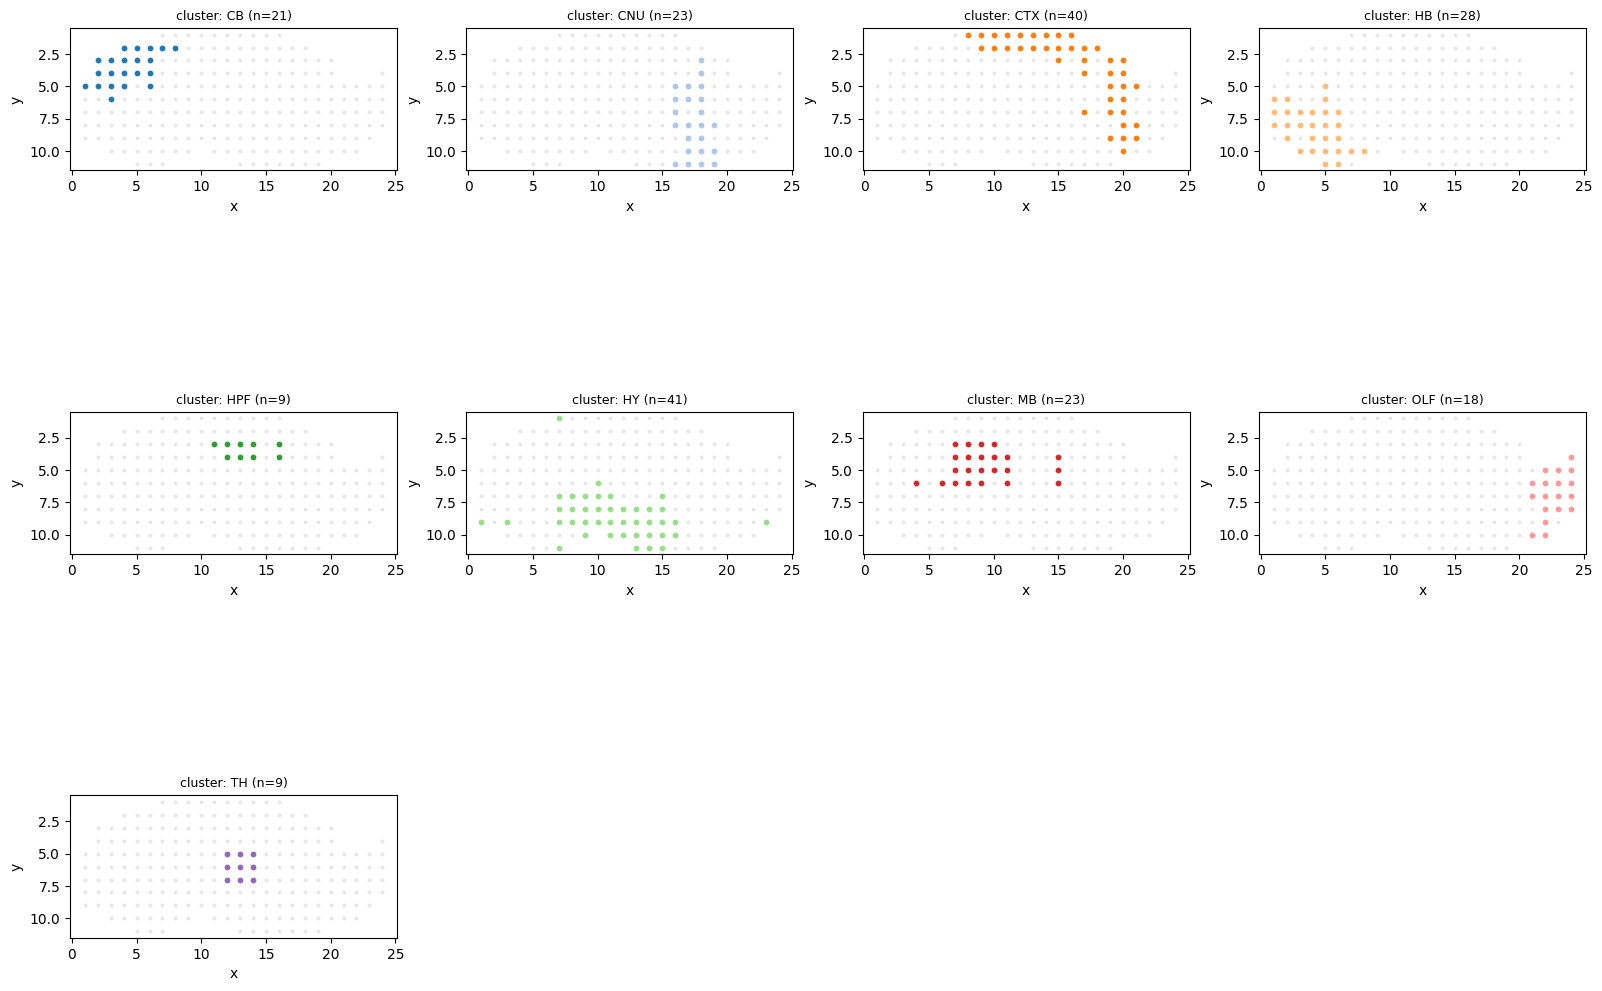

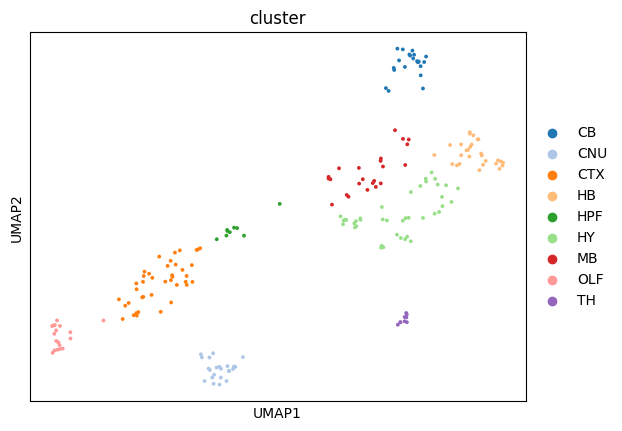

In [6]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from math import ceil
cluster_key  = "cluster"
invert_y = True
# ================== 5. 统一颜色 ==================
cats   = pd.Categorical(adata.obs[cluster_key])
labels = list(cats.categories.astype(str))
K      = len(labels)

# 生成一套颜色（tab20 循环）
cmap = cm.get_cmap("tab20", max(K, 20))
pal  = [mcolors.to_hex(cmap(i % cmap.N)) for i in range(K)]

# 让 scanpy 也用这套颜色
adata.uns[f"{cluster_key}_colors"] = pal

# ================== 6. 画“每个簇一张”的空间图 ==================
x = adata.obs["x"].to_numpy(float)
y = adata.obs["y"].to_numpy(float)

ncols = min(4, K)
nrows = ceil(K / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for i, lab in enumerate(labels):
    ax  = axes[i]
    sel = (cats == lab)
    # 背景灰
    ax.scatter(x, y, s=4, c=(0.8, 0.8, 0.8), alpha=0.35)
    # 当前簇高亮
    ax.scatter(x[sel], y[sel], s=10, c=pal[i])
    ax.set_title(f"{cluster_key}: {lab} (n={int(sel.sum())})", fontsize=9)
    ax.set_aspect("equal", adjustable="box")
    if invert_y:
        ax.invert_yaxis()
    ax.set_xlabel("x")
    ax.set_ylabel("y")

# 去掉多余子图
for j in range(K, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ================== 7. 画 UMAP（颜色跟上面一致） ==================
fig2 = sc.pl.umap(
    adata,
    color=cluster_key,
    size=30,
    show=False,
    return_fig=True,
)
plt.show()

In [29]:
import numpy as np
import pandas as pd
from pathlib import Path
import tifffile as tiff

# ---- 假定 adata 已经在内存里，且 adata.obs 里有 "x","y","cluster" ----
out_dir = Path("data/seq_relation"); out_dir.mkdir(parents=True, exist_ok=True)
tif_path = out_dir / "cluster_labels.tif"
lut_csv  = out_dir / "cluster_value_lut.csv"

# 取坐标
x = np.asarray(adata.obs["x"], dtype=float)
y = np.asarray(adata.obs["y"], dtype=float)

# 取 cluster，可能是字符串，比如 CTX / HY / ...，也可能有 NaN
clu = adata.obs["cluster"]

# 做一个稳定的顺序，把出现过的 cluster 排成 1,2,3,...
cats = pd.Categorical(clu)
names = list(cats.categories)   # e.g. ["CB","CNU","CTX",...]
name2id = {name: i+1 for i, name in enumerate(names)}  # 从 1 开始编号

# 把每个 spot 的 cluster 转成数字，没有的或 NaN 就是 0
clu_vals = []
for v in clu.astype(object).tolist():
    if v in name2id:
        clu_vals.append(name2id[v])
    else:
        clu_vals.append(0)
clu_vals = np.array(clu_vals, dtype=np.uint16)

# 构建规则网格
x_levels = np.sort(np.unique(x))
y_levels = np.sort(np.unique(y))
ix = np.searchsorted(x_levels, x)
iy = np.searchsorted(y_levels, y)

H = len(y_levels)
W = len(x_levels)
img = np.zeros((H, W), dtype=np.uint16)

# 填值：img[行=iy, 列=ix] = cluster_id
img[iy, ix] = clu_vals

# 如需把 y 轴翻过来再写：
# img = img[::-1, :]

# 保存 TIF
tiff.imwrite(str(tif_path), img)
print("Saved:", tif_path)

# 保存 LUT：数值 → cluster 名
lut = (
    pd.DataFrame({
        "cluster": names,
        "value": [name2id[n] for n in names]
    })
    .sort_values("value")
)
# 再加一行 0=unassigned
lut = pd.concat([
    pd.DataFrame([{"cluster": "unassigned", "value": 0}]),
    lut
], ignore_index=True)

lut.to_csv(lut_csv, index=False)
print("Saved:", lut_csv)


Saved: data\seq_relation\cluster_labels.tif
Saved: data\seq_relation\cluster_value_lut.csv


与测序数据的比较


In [ ]:
# ========= 基因×脑区矩阵；交集 → 每列总量归一到1e4 → log1p → 散点相关 =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

# --- 路径 ---
ref_path   = Path("data/seq_relation/REGION_ref_seq_data.csv")          # 参考：行=基因，列=脑区
slice_path = Path("data/seq_relation/slice_data.csv")  # 待比较：行=基因，列=脑区
out_dir    = Path("data/seq_relation/overlap_region_slice_scatter_lib1e4")
out_dir.mkdir(parents=True, exist_ok=True)

# --- 可调参数 ---
TARGET_SUM      = 10000.0     # 你说的“总表达量设为10000”
POINT_SIZE      = 8
POINT_ALPHA     = 0.6
DOT_EDGE_WIDTH  = 0.0
FIGSIZE_SINGLE  = (3.2, 3.2)
GRID_MAX_COLS   = 5
REFLINE_LW      = 1.0

# -------------------------------------------------------------
# 1. 读表
# -------------------------------------------------------------
ref_df   = pd.read_csv(ref_path,   header=0, index_col=0)
slice_df = pd.read_csv(slice_path, header=0, index_col=0)

# 转数值
ref_df   = ref_df.apply(pd.to_numeric, errors="coerce")
slice_df = slice_df.apply(pd.to_numeric, errors="coerce")

# -------------------------------------------------------------
# 2. 取交集
# -------------------------------------------------------------
regions_overlap = ref_df.columns.intersection(slice_df.columns)
genes_overlap   = ref_df.index.intersection(slice_df.index)

if len(regions_overlap) == 0:
    raise ValueError("两表没有重叠的脑区。")
if len(genes_overlap) == 0:
    raise ValueError("两表没有重叠的基因。")

# 按交集裁剪
ref2   = ref_df.loc[genes_overlap, regions_overlap].copy()
slice2 = slice_df.loc[genes_overlap, regions_overlap].copy()

# -------------------------------------------------------------
# 3. 每列把“交集基因的总表达量”归一到 TARGET_SUM
#    注意：我们对 ref 和 slice 分别做，但算法完全一样
# -------------------------------------------------------------
def normalize_cols_to_target(df: pd.DataFrame, target: float) -> pd.DataFrame:
    arr = df.to_numpy(float)
    col_sums = np.nansum(arr, axis=0)  # 每列对交集基因求和
    # 避免除0
    factors = np.ones_like(col_sums, dtype=float)
    nonzero = col_sums > 0
    factors[nonzero] = target / col_sums[nonzero]
    # 广播：行 × 列
    arr_norm = arr * factors
    return pd.DataFrame(arr_norm, index=df.index, columns=df.columns)

ref_norm   = normalize_cols_to_target(ref2,   TARGET_SUM)
slice_norm = normalize_cols_to_target(slice2, TARGET_SUM)

# -------------------------------------------------------------
# 4. log1p
# -------------------------------------------------------------
ref_log   = np.log1p(ref_norm)
slice_log = np.log1p(slice_norm)

# -------------------------------------------------------------
# 5. 按脑区散点 + 相关
# -------------------------------------------------------------
summary = []

for region in regions_overlap:
    x = ref_log[region].to_numpy(float)
    y = slice_log[region].to_numpy(float)

    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]; y = y[mask]
    n = len(x)
    if n < 3:
        continue

    r, _  = pearsonr(x, y)
    ro, _ = spearmanr(x, y)

    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE, dpi=300,facecolor="none")
    ax.scatter(
        x, y,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors='none' if DOT_EDGE_WIDTH == 0 else 'k',
        linewidths=DOT_EDGE_WIDTH
    )
    ax.plot([mn, mx], [mn, mx], color='gray', lw=REFLINE_LW, ls='--')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(region, fontsize=10)
    ax.set_xlabel("Reference (lib=1e4, log1p)", fontsize=9)
    ax.set_ylabel("Slice (lib=1e4, log1p)", fontsize=9)
    ax.text(
        0.02, 0.98,
        f"Pearson r={r:.3f}\nSpearman ρ={ro:.3f}\nN={n}",
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=8,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6)
    )
    fig.tight_layout()
    fig.savefig(out_dir / f"scatter_{region}.png", dpi=300)
    plt.close(fig)

    summary.append({
        "region": region,
        "n_genes": n,
        "pearson_r": r,
        "spearman_rho": ro
    })

# -------------------------------------------------------------
# 6. 汇总表
# -------------------------------------------------------------
summary_df = pd.DataFrame(summary).sort_values(
    ["pearson_r", "spearman_rho"], ascending=False
)
summary_df.to_csv(out_dir / "region_correlation_summary.csv", index=False)
print("Saved:", out_dir / "region_correlation_summary.csv")

# -------------------------------------------------------------
# 7. 总览网格
# -------------------------------------------------------------
regions_sorted = summary_df["region"].tolist()
if regions_sorted:
    n = len(regions_sorted)
    ncols = min(GRID_MAX_COLS, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * FIGSIZE_SINGLE[0], nrows * FIGSIZE_SINGLE[1]),
        dpi=200
    )
    axes = np.array(axes).reshape(-1)

    for i, region in enumerate(regions_sorted):
        ax = axes[i]

        x = ref_log[region].to_numpy(float)
        y = slice_log[region].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]; y = y[mask]

        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())

        r  = summary_df.loc[summary_df["region"] == region, "pearson_r"].values[0]
        ro = summary_df.loc[summary_df["region"] == region, "spearman_rho"].values[0]

        ax.scatter(
            x, y,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            edgecolors='none' if DOT_EDGE_WIDTH == 0 else 'k',
            linewidths=DOT_EDGE_WIDTH
        )
        ax.plot([mn, mx], [mn, mx], color='gray', lw=REFLINE_LW, ls='--')
        ax.set_xlim(mn, mx)
        ax.set_ylim(mn, mx)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f"{region}\nr={r:.2f}, ρ={ro:.2f}", fontsize=9)
        ax.tick_params(labelsize=8)

    # 删掉多余轴
    for j in range(len(regions_sorted), len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    fig.savefig(out_dir / "scatter_all_regions_grid.png", dpi=300)
    plt.close(fig)
    print("Saved:", out_dir / "scatter_all_regions_grid.png")

print(f"Done. 输出目录: {out_dir}")


Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\region_correlation_summary.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\scatter_all_regions_grid.png
Done. 输出目录: data\seq_relation\overlap_region_slice_scatter_lib1e4


In [35]:
# -------------------------------------------------------------
# 8. seq(=ref) × slices 的相关性热图（你前面这张）
# -------------------------------------------------------------
ref_mat   = ref_log   # genes × regions (ref)
slice_mat = slice_log # genes × regions (slice)

ref_regions   = ref_mat.columns.tolist()
slice_regions = slice_mat.columns.tolist()

# 8.1 ref × slice
cross_corr = np.zeros((len(ref_regions), len(slice_regions)), dtype=float)
for i, rname in enumerate(ref_regions):
    x = ref_mat[rname].to_numpy(float)
    for j, sname in enumerate(slice_regions):
        y = slice_mat[sname].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3:
            cross_corr[i, j] = np.nan
        else:
            cross_corr[i, j] = pearsonr(x[mask], y[mask])[0]

cross_df = pd.DataFrame(cross_corr, index=ref_regions, columns=slice_regions)
cross_df.to_csv(out_dir / "seq_vs_slice_correlation_matrix.csv")
print("Saved:", out_dir / "seq_vs_slice_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(0.4*len(slice_regions)+2, 0.4*len(ref_regions)+2), dpi=200)
im = ax.imshow(cross_corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(len(slice_regions)))
ax.set_yticks(np.arange(len(ref_regions)))
ax.set_xticklabels(slice_regions, rotation=90, fontsize=6)
ax.set_yticklabels(ref_regions, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.set_ylabel("Pearson r", fontsize=7)
ax.set_title("seq vs slices (lib=1e4, log1p)", fontsize=9)
fig.tight_layout()
fig.savefig(out_dir / "seq_vs_slice_heatmap.png", dpi=300)
plt.close(fig)
print("Saved:", out_dir / "seq_vs_slice_heatmap.png")


# -------------------------------------------------------------
# 9. seq 自身脑区间的相关性热图
# -------------------------------------------------------------
n_ref = len(ref_regions)
ref_self_corr = np.zeros((n_ref, n_ref), dtype=float)

for i, r1 in enumerate(ref_regions):
    x = ref_mat[r1].to_numpy(float)
    for j, r2 in enumerate(ref_regions):
        y = ref_mat[r2].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3:
            ref_self_corr[i, j] = np.nan
        else:
            ref_self_corr[i, j] = pearsonr(x[mask], y[mask])[0]

ref_self_df = pd.DataFrame(ref_self_corr, index=ref_regions, columns=ref_regions)
ref_self_df.to_csv(out_dir / "seq_self_correlation_matrix.csv")
print("Saved:", out_dir / "seq_self_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(0.4*n_ref+2, 0.4*n_ref+2), dpi=200)
im = ax.imshow(ref_self_corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(n_ref))
ax.set_yticks(np.arange(n_ref))
ax.set_xticklabels(ref_regions, rotation=90, fontsize=6)
ax.set_yticklabels(ref_regions, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.set_ylabel("Pearson r", fontsize=7)
ax.set_title("seq vs seq (lib=1e4, log1p)", fontsize=9)
fig.tight_layout()
fig.savefig(out_dir / "seq_self_heatmap.png", dpi=300)
plt.close(fig)
print("Saved:", out_dir / "seq_self_heatmap.png")


# -------------------------------------------------------------
# 10. slices 自身脑区间的相关性热图
# -------------------------------------------------------------
n_slice = len(slice_regions)
slice_self_corr = np.zeros((n_slice, n_slice), dtype=float)

for i, s1 in enumerate(slice_regions):
    x = slice_mat[s1].to_numpy(float)
    for j, s2 in enumerate(slice_regions):
        y = slice_mat[s2].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3:
            slice_self_corr[i, j] = np.nan
        else:
            slice_self_corr[i, j] = pearsonr(x[mask], y[mask])[0]

slice_self_df = pd.DataFrame(slice_self_corr, index=slice_regions, columns=slice_regions)
slice_self_df.to_csv(out_dir / "slice_self_correlation_matrix.csv")
print("Saved:", out_dir / "slice_self_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(0.4*n_slice+2, 0.4*n_slice+2), dpi=200)
im = ax.imshow(slice_self_corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(n_slice))
ax.set_yticks(np.arange(n_slice))
ax.set_xticklabels(slice_regions, rotation=90, fontsize=6)
ax.set_yticklabels(slice_regions, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.set_ylabel("Pearson r", fontsize=7)
ax.set_title("slices vs slices (lib=1e4, log1p)", fontsize=9)
fig.tight_layout()
fig.savefig(out_dir / "slice_self_heatmap.png", dpi=300)
plt.close(fig)
print("Saved:", out_dir / "slice_self_heatmap.png")


Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\seq_vs_slice_correlation_matrix.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\seq_vs_slice_heatmap.png
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\seq_self_correlation_matrix.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\seq_self_heatmap.png
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\slice_self_correlation_matrix.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4\slice_self_heatmap.png


修改脑区注释后计算相关性


In [ ]:
# ========= 基因×脑区矩阵；交集 → 每列总量归一到1e4 → log1p → 散点相关 =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

# --- 路径 ---
ref_path   = Path("data/seq_relation/REGION_ref_seq_data.csv")          # 参考：行=基因，列=脑区
slice_path = Path("data/seq_relation/slice_data_filtered.csv")  # 待比较：行=基因，列=脑区
out_dir    = Path("data/seq_relation/overlap_region_slice_scatter_lib1e4_filtered")
out_dir.mkdir(parents=True, exist_ok=True)

# --- 可调参数 ---
TARGET_SUM      = 10000.0     # 你说的“总表达量设为10000”
POINT_SIZE      = 8
POINT_ALPHA     = 0.6
DOT_EDGE_WIDTH  = 0.0
FIGSIZE_SINGLE  = (3.2, 3.2)
GRID_MAX_COLS   = 5
REFLINE_LW      = 1.0

# -------------------------------------------------------------
# 1. 读表
# -------------------------------------------------------------
ref_df   = pd.read_csv(ref_path,   header=0, index_col=0)
slice_df = pd.read_csv(slice_path, header=0, index_col=0)

# 转数值
ref_df   = ref_df.apply(pd.to_numeric, errors="coerce")
slice_df = slice_df.apply(pd.to_numeric, errors="coerce")

# -------------------------------------------------------------
# 2. 取交集
# -------------------------------------------------------------
regions_overlap = ref_df.columns.intersection(slice_df.columns)
genes_overlap   = ref_df.index.intersection(slice_df.index)

if len(regions_overlap) == 0:
    raise ValueError("两表没有重叠的脑区。")
if len(genes_overlap) == 0:
    raise ValueError("两表没有重叠的基因。")

# 按交集裁剪
ref2   = ref_df.loc[genes_overlap, regions_overlap].copy()
slice2 = slice_df.loc[genes_overlap, regions_overlap].copy()

# -------------------------------------------------------------
# 3. 每列把“交集基因的总表达量”归一到 TARGET_SUM
#    注意：我们对 ref 和 slice 分别做，但算法完全一样
# -------------------------------------------------------------
def normalize_cols_to_target(df: pd.DataFrame, target: float) -> pd.DataFrame:
    arr = df.to_numpy(float)
    col_sums = np.nansum(arr, axis=0)  # 每列对交集基因求和
    # 避免除0
    factors = np.ones_like(col_sums, dtype=float)
    nonzero = col_sums > 0
    factors[nonzero] = target / col_sums[nonzero]
    # 广播：行 × 列
    arr_norm = arr * factors
    return pd.DataFrame(arr_norm, index=df.index, columns=df.columns)

ref_norm   = normalize_cols_to_target(ref2,   TARGET_SUM)
slice_norm = normalize_cols_to_target(slice2, TARGET_SUM)

# -------------------------------------------------------------
# 4. log1p
# -------------------------------------------------------------
ref_log   = np.log1p(ref_norm)
slice_log = np.log1p(slice_norm)

# -------------------------------------------------------------
# 5. 按脑区散点 + 相关
# -------------------------------------------------------------
summary = []

for region in regions_overlap:
    x = ref_log[region].to_numpy(float)
    y = slice_log[region].to_numpy(float)

    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]; y = y[mask]
    n = len(x)
    if n < 3:
        continue

    r, _  = pearsonr(x, y)
    ro, _ = spearmanr(x, y)

    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())

    fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE, dpi=300,)
    ax.scatter(
        x, y,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors='none' if DOT_EDGE_WIDTH == 0 else 'k',
        linewidths=DOT_EDGE_WIDTH
    )
    ax.plot([mn, mx], [mn, mx], color='gray', lw=REFLINE_LW, ls='--')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(region, fontsize=10)
    ax.set_xlabel("Reference (lib=1e4, log1p)", fontsize=9)
    ax.set_ylabel("Slice (lib=1e4, log1p)", fontsize=9)
    ax.text(
        0.02, 0.98,
        f"Pearson r={r:.3f}\nSpearman ρ={ro:.3f}\nN={n}",
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=8,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.6)
    )
    fig.tight_layout()
    fig.savefig(out_dir / f"scatter_{region}.png", dpi=300)
    plt.close(fig)

    summary.append({
        "region": region,
        "n_genes": n,
        "pearson_r": r,
        "spearman_rho": ro
    })

# -------------------------------------------------------------
# 6. 汇总表
# -------------------------------------------------------------
summary_df = pd.DataFrame(summary).sort_values(
    ["pearson_r", "spearman_rho"], ascending=False
)
summary_df.to_csv(out_dir / "region_correlation_summary.csv", index=False)
print("Saved:", out_dir / "region_correlation_summary.csv")

# -------------------------------------------------------------
# 7. 总览网格
# -------------------------------------------------------------
regions_sorted = summary_df["region"].tolist()
if regions_sorted:
    n = len(regions_sorted)
    ncols = min(GRID_MAX_COLS, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * FIGSIZE_SINGLE[0], nrows * FIGSIZE_SINGLE[1]),
        dpi=200
    )
    axes = np.array(axes).reshape(-1)

    for i, region in enumerate(regions_sorted):
        ax = axes[i]

        x = ref_log[region].to_numpy(float)
        y = slice_log[region].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        x = x[mask]; y = y[mask]

        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())

        r  = summary_df.loc[summary_df["region"] == region, "pearson_r"].values[0]
        ro = summary_df.loc[summary_df["region"] == region, "spearman_rho"].values[0]

        ax.scatter(
            x, y,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            edgecolors='none' if DOT_EDGE_WIDTH == 0 else 'k',
            linewidths=DOT_EDGE_WIDTH
        )
        ax.plot([mn, mx], [mn, mx], color='gray', lw=REFLINE_LW, ls='--')
        ax.set_xlim(mn, mx)
        ax.set_ylim(mn, mx)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(f"{region}\nr={r:.2f}, ρ={ro:.2f}", fontsize=9)
        ax.tick_params(labelsize=8)

    # 删掉多余轴
    for j in range(len(regions_sorted), len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    fig.savefig(out_dir / "scatter_all_regions_grid.png", dpi=300)
    plt.close(fig)
    print("Saved:", out_dir / "scatter_all_regions_grid.png")

print(f"Done. 输出目录: {out_dir}")


Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\region_correlation_summary.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\scatter_all_regions_grid.png
Done. 输出目录: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered


In [37]:
# -------------------------------------------------------------
# 8. seq(=ref) × slices 的相关性热图（你前面这张）
# -------------------------------------------------------------
ref_mat   = ref_log   # genes × regions (ref)
slice_mat = slice_log # genes × regions (slice)

ref_regions   = ref_mat.columns.tolist()
slice_regions = slice_mat.columns.tolist()

# 8.1 ref × slice
cross_corr = np.zeros((len(ref_regions), len(slice_regions)), dtype=float)
for i, rname in enumerate(ref_regions):
    x = ref_mat[rname].to_numpy(float)
    for j, sname in enumerate(slice_regions):
        y = slice_mat[sname].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3:
            cross_corr[i, j] = np.nan
        else:
            cross_corr[i, j] = pearsonr(x[mask], y[mask])[0]

cross_df = pd.DataFrame(cross_corr, index=ref_regions, columns=slice_regions)
cross_df.to_csv(out_dir / "seq_vs_slice_correlation_matrix.csv")
print("Saved:", out_dir / "seq_vs_slice_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(0.4*len(slice_regions)+2, 0.4*len(ref_regions)+2), dpi=200)
im = ax.imshow(cross_corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(len(slice_regions)))
ax.set_yticks(np.arange(len(ref_regions)))
ax.set_xticklabels(slice_regions, rotation=90, fontsize=6)
ax.set_yticklabels(ref_regions, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.set_ylabel("Pearson r", fontsize=7)
ax.set_title("seq vs slices (lib=1e4, log1p)", fontsize=9)
fig.tight_layout()
fig.savefig(out_dir / "seq_vs_slice_heatmap.png", dpi=300)
plt.close(fig)
print("Saved:", out_dir / "seq_vs_slice_heatmap.png")


# -------------------------------------------------------------
# 9. seq 自身脑区间的相关性热图
# -------------------------------------------------------------
n_ref = len(ref_regions)
ref_self_corr = np.zeros((n_ref, n_ref), dtype=float)

for i, r1 in enumerate(ref_regions):
    x = ref_mat[r1].to_numpy(float)
    for j, r2 in enumerate(ref_regions):
        y = ref_mat[r2].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3:
            ref_self_corr[i, j] = np.nan
        else:
            ref_self_corr[i, j] = pearsonr(x[mask], y[mask])[0]

ref_self_df = pd.DataFrame(ref_self_corr, index=ref_regions, columns=ref_regions)
ref_self_df.to_csv(out_dir / "seq_self_correlation_matrix.csv")
print("Saved:", out_dir / "seq_self_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(0.4*n_ref+2, 0.4*n_ref+2), dpi=200)
im = ax.imshow(ref_self_corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(n_ref))
ax.set_yticks(np.arange(n_ref))
ax.set_xticklabels(ref_regions, rotation=90, fontsize=6)
ax.set_yticklabels(ref_regions, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.set_ylabel("Pearson r", fontsize=7)
ax.set_title("seq vs seq (lib=1e4, log1p)", fontsize=9)
fig.tight_layout()
fig.savefig(out_dir / "seq_self_heatmap.png", dpi=300)
plt.close(fig)
print("Saved:", out_dir / "seq_self_heatmap.png")


# -------------------------------------------------------------
# 10. slices 自身脑区间的相关性热图
# -------------------------------------------------------------
n_slice = len(slice_regions)
slice_self_corr = np.zeros((n_slice, n_slice), dtype=float)

for i, s1 in enumerate(slice_regions):
    x = slice_mat[s1].to_numpy(float)
    for j, s2 in enumerate(slice_regions):
        y = slice_mat[s2].to_numpy(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3:
            slice_self_corr[i, j] = np.nan
        else:
            slice_self_corr[i, j] = pearsonr(x[mask], y[mask])[0]

slice_self_df = pd.DataFrame(slice_self_corr, index=slice_regions, columns=slice_regions)
slice_self_df.to_csv(out_dir / "slice_self_correlation_matrix.csv")
print("Saved:", out_dir / "slice_self_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(0.4*n_slice+2, 0.4*n_slice+2), dpi=200)
im = ax.imshow(slice_self_corr, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(n_slice))
ax.set_yticks(np.arange(n_slice))
ax.set_xticklabels(slice_regions, rotation=90, fontsize=6)
ax.set_yticklabels(slice_regions, fontsize=6)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.set_ylabel("Pearson r", fontsize=7)
ax.set_title("slices vs slices (lib=1e4, log1p)", fontsize=9)
fig.tight_layout()
fig.savefig(out_dir / "slice_self_heatmap.png", dpi=300)
plt.close(fig)
print("Saved:", out_dir / "slice_self_heatmap.png")


Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\seq_vs_slice_correlation_matrix.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\seq_vs_slice_heatmap.png
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\seq_self_correlation_matrix.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\seq_self_heatmap.png
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\slice_self_correlation_matrix.csv
Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered\slice_self_heatmap.png


正式绘图

In [48]:
# ========= 基因×脑区矩阵；交集 → 每列总量归一到1e4 → log1p → 单脑区 3cm×3cm 散点 =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

# --- 路径 ---
ref_path   = Path("data/seq_relation/REGION_ref_seq_data.csv")          # 参考：行=基因，列=脑区
slice_path = Path("data/seq_relation/slice_data_filtered.csv")          # 待比较：行=基因，列=脑区
out_dir    = Path("data/seq_relation/overlap_region_slice_scatter_lib1e4_filtered_paper")
out_dir.mkdir(parents=True, exist_ok=True)

# --- 参数 ---
TARGET_SUM = 10000.0   # 列归一目标
POINT_SIZE = 8
POINT_ALPHA = 0.6
DOT_EDGE_WIDTH = 0.0
REFLINE_LW = 0.7

# 3 cm × 3 cm -> inch
cm2in = 1 / 2.54
ax_w_in = 3.0 * cm2in
ax_h_in = 3.0 * cm2in
# 给一点边距，不然文字没地方放
left_in   = 0.35
bottom_in = 0.25
right_in  = 0.55
top_in    = 0.15

fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

# 全局字体
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

# -------------------------------------------------------------
# 1. 读表
# -------------------------------------------------------------
ref_df   = pd.read_csv(ref_path,   header=0, index_col=0)
slice_df = pd.read_csv(slice_path, header=0, index_col=0)

ref_df   = ref_df.apply(pd.to_numeric, errors="coerce")
slice_df = slice_df.apply(pd.to_numeric, errors="coerce")

# -------------------------------------------------------------
# 2. 交集
# -------------------------------------------------------------
regions_overlap = ref_df.columns.intersection(slice_df.columns)
genes_overlap   = ref_df.index.intersection(slice_df.index)

if len(regions_overlap) == 0:
    raise ValueError("两表没有重叠的脑区。")
if len(genes_overlap) == 0:
    raise ValueError("两表没有重叠的基因。")

ref2   = ref_df.loc[genes_overlap, regions_overlap].copy()
slice2 = slice_df.loc[genes_overlap, regions_overlap].copy()

# -------------------------------------------------------------
# 3. 列归一到 1e4
# -------------------------------------------------------------
def normalize_cols_to_target(df: pd.DataFrame, target: float) -> pd.DataFrame:
    arr = df.to_numpy(float)
    col_sums = np.nansum(arr, axis=0)
    factors = np.ones_like(col_sums, dtype=float)
    nonzero = col_sums > 0
    factors[nonzero] = target / col_sums[nonzero]
    arr_norm = arr * factors
    return pd.DataFrame(arr_norm, index=df.index, columns=df.columns)

ref_norm   = normalize_cols_to_target(ref2,   TARGET_SUM)
slice_norm = normalize_cols_to_target(slice2, TARGET_SUM)

# -------------------------------------------------------------
# 4. log1p
# -------------------------------------------------------------
ref_log   = np.log1p(ref_norm)
slice_log = np.log1p(slice_norm)

# -------------------------------------------------------------
# 5. 按脑区画单图（3cm×3cm）
# -------------------------------------------------------------
summary = []

for region in regions_overlap:
    x = ref_log[region].to_numpy(float)
    y = slice_log[region].to_numpy(float)

    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]; y = y[mask]
    n = len(x)
    if n < 3:
        continue

    r, _  = pearsonr(x, y)
    ro, _ = spearmanr(x, y)

    # 坐标范围统一一下
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())

    # figure 背景透明
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")
    # 精确放一个 3cm×3cm 的轴
    ax = fig.add_axes([
        left_in / fig_w,
        bottom_in / fig_h,
        ax_w_in / fig_w,
        ax_h_in / fig_h
    ])

    ax.scatter(
        x, y,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors='none' if DOT_EDGE_WIDTH == 0 else 'k',
        linewidths=DOT_EDGE_WIDTH
    )
    ax.plot([mn, mx], [mn, mx], color='gray', lw=REFLINE_LW, ls='--')

    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal', adjustable='box')

    # 轴标签 7pt
    ax.set_xlabel(f"RNA seq expression\n(lib=1e4, log1p)", fontsize=7)
    ax.set_ylabel(f"SLICES expression\n(lib=1e4, log1p)", fontsize=7)
    ax.set_title(region, fontsize=7)

    # 文字说明放在轴内右上角
    ax.text(
        0.02, 0.98,
        f"r={r:.3f}\nρ={ro:.3f}",
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=7,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0),
    )

    # 保存三种格式，透明
    stem = out_dir / f"scatter_{region}_3x3cm"
    fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.03, transparent=True)
    fig.savefig(stem.with_suffix(".pdf"),              bbox_inches="tight", pad_inches=0.03, transparent=True)
    fig.savefig(stem.with_suffix(".svg"),              bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)

    summary.append({
        "region": region,
        "n_genes": n,
        "pearson_r": r,
        "spearman_rho": ro
    })

# -------------------------------------------------------------
# 6. 汇总表
# -------------------------------------------------------------
summary_df = pd.DataFrame(summary).sort_values(
    ["pearson_r", "spearman_rho"], ascending=False
)
summary_df.to_csv(out_dir / "region_correlation_summary.csv", index=False)
print("Saved:", out_dir / "region_correlation_summary.csv")
print(f"Done. 单脑区散点已输出到: {out_dir}")


Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered_paper\region_correlation_summary.csv
Done. 单脑区散点已输出到: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered_paper


正式绘图，无标题

In [49]:
# ========= 基因×脑区矩阵；交集 → 每列总量归一到1e4 → log1p → 单脑区 3cm×3cm 散点 =========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

# --- 路径 ---
ref_path   = Path("data/seq_relation/REGION_ref_seq_data.csv")          # 参考：行=基因，列=脑区
slice_path = Path("data/seq_relation/slice_data_filtered.csv")          # 待比较：行=基因，列=脑区
out_dir    = Path("data/seq_relation/overlap_region_slice_scatter_lib1e4_filtered_paper")
out_dir.mkdir(parents=True, exist_ok=True)

# --- 参数 ---
TARGET_SUM = 10000.0   # 列归一目标
POINT_SIZE = 8
POINT_ALPHA = 0.6
DOT_EDGE_WIDTH = 0.0
REFLINE_LW = 0.7

# 3 cm × 3 cm -> inch
cm2in = 1 / 2.54
ax_w_in = 3.0 * cm2in
ax_h_in = 3.0 * cm2in
# 给一点边距，不然文字没地方放
left_in   = 0.35
bottom_in = 0.25
right_in  = 0.55
top_in    = 0.15

fig_w = left_in + ax_w_in + right_in
fig_h = bottom_in + ax_h_in + top_in

# 全局字体
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

# -------------------------------------------------------------
# 1. 读表
# -------------------------------------------------------------
ref_df   = pd.read_csv(ref_path,   header=0, index_col=0)
slice_df = pd.read_csv(slice_path, header=0, index_col=0)

ref_df   = ref_df.apply(pd.to_numeric, errors="coerce")
slice_df = slice_df.apply(pd.to_numeric, errors="coerce")

# -------------------------------------------------------------
# 2. 交集
# -------------------------------------------------------------
regions_overlap = ref_df.columns.intersection(slice_df.columns)
genes_overlap   = ref_df.index.intersection(slice_df.index)

if len(regions_overlap) == 0:
    raise ValueError("两表没有重叠的脑区。")
if len(genes_overlap) == 0:
    raise ValueError("两表没有重叠的基因。")

ref2   = ref_df.loc[genes_overlap, regions_overlap].copy()
slice2 = slice_df.loc[genes_overlap, regions_overlap].copy()

# -------------------------------------------------------------
# 3. 列归一到 1e4
# -------------------------------------------------------------
def normalize_cols_to_target(df: pd.DataFrame, target: float) -> pd.DataFrame:
    arr = df.to_numpy(float)
    col_sums = np.nansum(arr, axis=0)
    factors = np.ones_like(col_sums, dtype=float)
    nonzero = col_sums > 0
    factors[nonzero] = target / col_sums[nonzero]
    arr_norm = arr * factors
    return pd.DataFrame(arr_norm, index=df.index, columns=df.columns)

ref_norm   = normalize_cols_to_target(ref2,   TARGET_SUM)
slice_norm = normalize_cols_to_target(slice2, TARGET_SUM)

# -------------------------------------------------------------
# 4. log1p
# -------------------------------------------------------------
ref_log   = np.log1p(ref_norm)
slice_log = np.log1p(slice_norm)

# -------------------------------------------------------------
# 5. 按脑区画单图（3cm×3cm）
# -------------------------------------------------------------
summary = []

for region in regions_overlap:
    x = ref_log[region].to_numpy(float)
    y = slice_log[region].to_numpy(float)

    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]; y = y[mask]
    n = len(x)
    if n < 3:
        continue

    r, _  = pearsonr(x, y)
    ro, _ = spearmanr(x, y)

    # 坐标范围统一一下
    mn = min(x.min(), y.min())
    mx = max(x.max(), y.max())

    # figure 背景透明
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=300, facecolor="none")
    # 精确放一个 3cm×3cm 的轴
    ax = fig.add_axes([
        left_in / fig_w,
        bottom_in / fig_h,
        ax_w_in / fig_w,
        ax_h_in / fig_h
    ])

    ax.scatter(
        x, y,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        edgecolors='none' if DOT_EDGE_WIDTH == 0 else 'k',
        linewidths=DOT_EDGE_WIDTH
    )
    ax.plot([mn, mx], [mn, mx], color='gray', lw=REFLINE_LW, ls='--')

    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_aspect('equal', adjustable='box')

    # 轴标签 7pt
    ax.set_xlabel(f" ", fontsize=7)
    ax.set_ylabel(f" ", fontsize=7)
    ax.set_title(region, fontsize=7)

    # 文字说明放在轴内右上角
    ax.text(
        0.02, 0.98,
        f"r={r:.3f}\nρ={ro:.3f}",
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=7,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0),
    )

    # 保存三种格式，透明
    stem = out_dir / f"scatter_{region}_3x3cm_no_title"
    fig.savefig(stem.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.03, transparent=True)
    fig.savefig(stem.with_suffix(".pdf"),              bbox_inches="tight", pad_inches=0.03, transparent=True)
    fig.savefig(stem.with_suffix(".svg"),              bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)

    summary.append({
        "region": region,
        "n_genes": n,
        "pearson_r": r,
        "spearman_rho": ro
    })

# -------------------------------------------------------------
# 6. 汇总表
# -------------------------------------------------------------
summary_df = pd.DataFrame(summary).sort_values(
    ["pearson_r", "spearman_rho"], ascending=False
)
summary_df.to_csv(out_dir / "region_correlation_summary.csv", index=False)
print("Saved:", out_dir / "region_correlation_summary.csv")
print(f"Done. 单脑区散点已输出到: {out_dir}")


Saved: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered_paper\region_correlation_summary.csv
Done. 单脑区散点已输出到: data\seq_relation\overlap_region_slice_scatter_lib1e4_filtered_paper
